<a href="https://colab.research.google.com/github/yudithvega-art/bhm-mrsa-indonesia/blob/main/Exposure_Dose_and_Sensitivity_05082026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Monte Carlo: 10000 iterations per farm

    matrix farm  median_CFU  p05_CFU    p95_CFU  median_log10
      Milk F-02     21.1382   0.9953   706.7595        1.3251
      Milk F-05    163.5316  17.4029  1790.5149        2.2136
      Milk F-07     60.4644   5.0918   992.5707        1.7815
      Milk F-08    415.3272  29.5639  4597.1982        2.6184
      Milk F-09    458.1967  33.0111  5288.8289        2.6611
      Milk F-10    709.2110  38.7746 10623.4030        2.8508
     Water F-02      1.5143   0.3534     6.4642        0.1802
     Water F-03      0.1655   0.0092     1.0398       -0.7811
     Water F-04      0.2180   0.0152     1.4317       -0.6615
     Water F-05      1.2240   0.3082     4.7449        0.0878
     Water F-06      0.6908   0.1873     2.3401       -0.1606
     Water F-07      0.2121   0.0130     1.3111       -0.6734
     Water F-08      0.9316   0.2554     3.1174       -0.0308
     Water F-09      0.6737   0.1609     2.3013       -0.1715
     Water F-10      0.1650   

/tmp/ipykernel_946/3802500590.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.05, 1, 1))



Saved: mc_dose_summary.csv, mc_exposure_dose_ridgeline.png


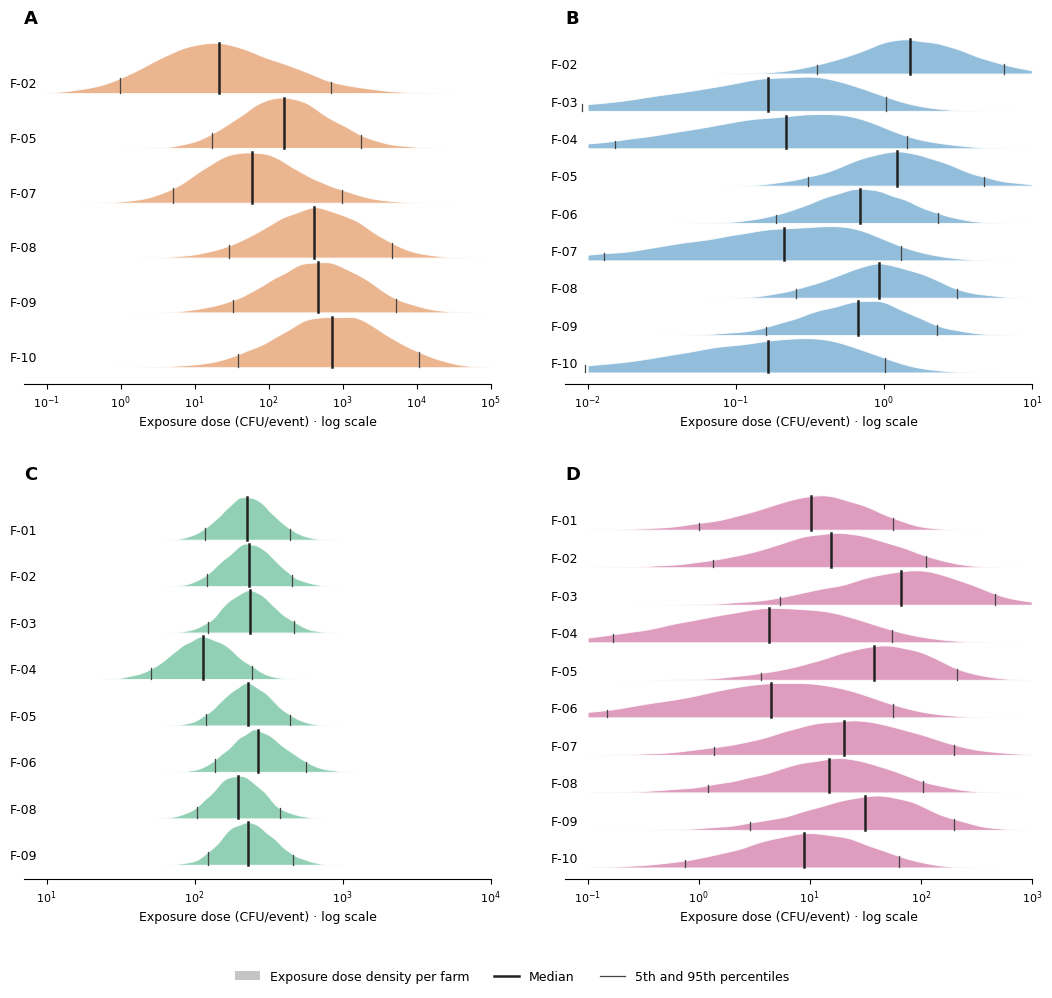

In [8]:
"""
mc_exposure_dose.py
------------------------------------------------------------------------------
Monte Carlo exposure-dose estimation (10,000 iterations) per farm and matrix,
rendered as a four-panel ridgeline figure matching the manuscript layout:

    A  Milk        (CFU/event)  orange
    B  Water       (CFU/event)  blue
    C  Bioaerosol  (CFU/hour)   green   <- inhalation rate only, not x shift
    D  EnvDust     (CFU/event)  pink

Concentration draws are reconstructed per farm from the BHM posterior summary
(median + asymmetric 95% CI) in bhm_full_mu_F.csv using a split-normal, then
propagated through the pathway-specific exposure model on the log10 scale.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy.stats import gaussian_kde

RNG = np.random.default_rng(2026)
N_ITER = 10_000
Z = 1.959963985

MU_F = "bhm_full_mu_F.csv"

# Panel order, unit, colour, and x-limits (log10) to match the figure.
# Layout is 2x2:  A B  /  C D
PANELS = {
    "Milk":       dict(letter="A", unit="CFU/event", colour="#E8A87C",
                       xlim=(-1, 5)),
    "Water":      dict(letter="B", unit="CFU/event", colour="#7FB3D5",
                       xlim=(-2, 1)),
    "Bioaerosol": dict(letter="C", unit="CFU/event", colour="#7FC8A9",
                       xlim=(1, 4)),
    "EnvDust":    dict(letter="D", unit="CFU/event", colour="#D98CB3",
                       xlim=(-1, 3)),
}

# Base-case exposure parameters (Section 2.4)
V_MILK_WATER = 1.0        # mL/event
IR_BIOAEROSOL = 0.48      # m3/h
SHIFT_HOURS = 8.0         # one event = one full shift -> CFU/event

# Dust contacted-area definition:
#   "hand_area"     A_contact = Uniform(445,535) cm2 * Uniform(0.008,0.25)
#                   = 3.56-133.75 cm2   (Section 2.4 as written)
#   "fraction_only" A_contact = Uniform(0.008,0.25)   (~1 cm2 reference area)
#                   reproduces the attached figure (panel D, 1e-3..1e0)
DUST_AREA_MODE = "hand_area"


# ---------------------------------------------------------------------------
# Concentration draws from median + asymmetric 95% CI (split-normal)
# ---------------------------------------------------------------------------
def split_normal(median, q025, q975, n=N_ITER):
    sd_lo = max((median - q025) / Z, 1e-6)
    sd_hi = max((q975 - median) / Z, 1e-6)
    u = RNG.random(n)
    p_lo = sd_lo / (sd_lo + sd_hi)
    out = np.empty(n)
    lo = u < p_lo
    out[lo] = median - np.abs(RNG.normal(0, sd_lo, lo.sum()))
    out[~lo] = median + np.abs(RNG.normal(0, sd_hi, (~lo).sum()))
    return out


# ---------------------------------------------------------------------------
# Exposure-parameter draws for dust
# ---------------------------------------------------------------------------
def dust_params(n=N_ITER):
    frac = RNG.uniform(0.008, 0.25, n)
    if DUST_AREA_MODE == "hand_area":
        A = RNG.uniform(445, 535, n) * frac            # 3.56-133.75 cm2
    else:                                              # "fraction_only"
        A = frac                                       # ~1 cm2 reference
    TE_sh = RNG.triangular(0.01, 0.208, 0.406, n)
    TE_hm = RNG.normal(0.339, 0.132, n)
    return A, TE_sh, TE_hm


# ---------------------------------------------------------------------------
# Log10 dose per matrix for one farm's concentration draws
# ---------------------------------------------------------------------------
def log10_dose(matrix, logC):
    if matrix in ("Milk", "Water"):
        return logC + np.log10(V_MILK_WATER)
    if matrix == "Bioaerosol":
        return logC + np.log10(IR_BIOAEROSOL * SHIFT_HOURS)   # CFU/event
    if matrix == "EnvDust":
        A, sh, hm = dust_params(len(logC))
        good = (sh > 0) & (hm > 0)
        d = np.full(len(logC), np.nan)
        d[good] = (logC[good] + np.log10(A[good])
                   + np.log10(sh[good]) + np.log10(hm[good]))
        return d[np.isfinite(d)]
    raise ValueError(matrix)


# ---------------------------------------------------------------------------
# Run Monte Carlo for every farm x matrix
# ---------------------------------------------------------------------------
def run(df):
    results, summary = {}, []
    for matrix in PANELS:
        sub = df[df.matrix == matrix].sort_values("farm")
        results[matrix] = {}
        for _, r in sub.iterrows():
            logC = split_normal(r["median"], r["q025"], r["q975"])
            logD = log10_dose(matrix, logC)
            results[matrix][r["farm"]] = logD
            lin = 10.0 ** logD
            summary.append(dict(
                matrix=matrix, farm=r["farm"],
                median_CFU=np.median(lin),
                p05_CFU=np.percentile(lin, 5),
                p95_CFU=np.percentile(lin, 95),
                median_log10=np.median(logD)))
    return results, pd.DataFrame(summary)


# ---------------------------------------------------------------------------
# Ridgeline figure
# ---------------------------------------------------------------------------
def ridgeline(results):
    order = ["Milk", "Water", "Bioaerosol", "EnvDust"]   # A B / C D
    # tinggi tiap baris proporsional terhadap jumlah peternakan terbanyak
    n_top = max(len(results["Milk"]), len(results["Water"]))
    n_bot = max(len(results["Bioaerosol"]), len(results["EnvDust"]))
    fig, axes = plt.subplots(
        2, 2, figsize=(13, 11),
        gridspec_kw=dict(height_ratios=[n_top, n_bot], hspace=0.28, wspace=0.16))

    for ax, matrix in zip(axes.flat, order):
        cfg = PANELS[matrix]
        farms = sorted(results[matrix], reverse=True)     # top-to-bottom
        gap = 1.0
        overlap = 0.92                                     # ridge nyaris tak bertumpuk
        xspan = cfg["xlim"][1] - cfg["xlim"][0]
        xg = np.linspace(cfg["xlim"][0], cfg["xlim"][1], 400)
        for i, farm in enumerate(farms):
            logD = results[matrix][farm]
            base = i * gap
            dens = gaussian_kde(logD)(xg)
            dens = dens / dens.max() * (gap * overlap)
            ax.fill_between(xg, base, base + dens, color=cfg["colour"],
                            alpha=0.85, linewidth=0.8, edgecolor="white",
                            zorder=len(farms) - i)
            med = np.median(logD)
            p05, p95 = np.percentile(logD, [5, 95])
            ax.plot([med, med], [base, base + np.interp(med, xg, dens)],
                    color="#222", lw=1.8, zorder=len(farms) - i + 0.5)
            for p in (p05, p95):
                ax.plot([p, p], [base, base + np.interp(p, xg, dens)],
                        color="#444", lw=0.9, zorder=len(farms) - i + 0.5)
            ax.text(cfg["xlim"][0] - 0.02 * xspan, base + 0.05, farm,
                    ha="right", va="bottom", fontsize=9)
        ax.set_xlim(cfg["xlim"][0] - 0.05 * xspan, cfg["xlim"][1])
        ax.set_ylim(-0.3, (len(farms) - 1) * gap + gap * overlap + 0.2)
        ax.set_yticks([])
        ticks = np.arange(cfg["xlim"][0], cfg["xlim"][1] + 1)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"$10^{{{int(t)}}}$" for t in ticks], fontsize=8)
        ax.set_xlabel(f"Exposure dose ({cfg['unit']}) · log scale", fontsize=9)
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)
        ax.set_title(cfg["letter"], loc="left", fontweight="bold", fontsize=13)

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    handles = [Patch(facecolor="#bbb", alpha=0.85,
                     label="Exposure dose density per farm"),
               Line2D([0], [0], color="#222", lw=1.8, label="Median"),
               Line2D([0], [0], color="#444", lw=0.9,
                      label="5th and 95th percentiles")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
               fontsize=9, bbox_to_anchor=(0.5, 0.005))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    return fig


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    df = pd.read_csv(MU_F)
    results, summary = run(df)

    print(f"Monte Carlo: {N_ITER} iterations per farm\n")
    print(summary.round(4).to_string(index=False))
    summary.to_csv("mc_dose_summary.csv", index=False)

    fig = ridgeline(results)
    fig.savefig("mc_exposure_dose_ridgeline.png", dpi=150,
                bbox_inches="tight")
    print("\nSaved: mc_dose_summary.csv, mc_exposure_dose_ridgeline.png")

In [9]:
"""
sensitivity_analysis.py
------------------------------------------------------------------------------
Sensitivity analysis of MRSA per-event exposure dose to the exposure
assumptions, using three scenarios (low / default / conservative) per matrix.

Scenarios (as specified):
    Milk, Water   ingestion volume V = 0.1, 1.0, 5.0 mL/event
    Bioaerosol    inhalation rate IR = 0.24, 0.48, 0.96 m3/h, paired with an
                  8 h shift -> air volume = 1.92, 3.84, 7.68 m3/event
                  (light / moderate / heavy work intensity)
    Env. dust     area-based transfer, three parameters tested separately:
                    A_contact       = 3.6, 45, 133.75 cm2/event
                    TE_surface_hand = 0.01, 0.208, 0.406   (tri min/mode/max)
                    TE_hand_mouth   = 0.207, 0.339, 0.471   (mean +/- 1 SD)

In each scenario the tested parameter is set to its scenario value while all
other inputs remain at their default distributions. Median and 95th-percentile
per-event doses (CFU/event) are compared across scenarios.

Sensitivity range (delta, Δ) = relative change in the MEDIAN per-event dose
between the highest- and lowest-dose scenarios, expressed as a percentage of
the default-scenario median, averaged across all sampling points (farms)
within each matrix:

        Δ = mean_over_farms( (median_high - median_low) / median_default ) * 100

Concentration draws per farm are reconstructed from the BHM posterior summary
(bhm_full_mu_F.csv: median + asymmetric 95% CI) via a split-normal, identical
to the Monte Carlo dose script, so results are directly comparable.
"""

from __future__ import annotations

import numpy as np
import pandas as pd

RNG = np.random.default_rng(2026)
N_ITER = 10_000
Z = 1.959963985
MU_F = "bhm_full_mu_F.csv"

# ---- default (base-case) exposure parameters (Section 2.4) ----
V_MILK_WATER = 1.0          # mL/event
IR_BIOAEROSOL = 0.48        # m3/h
SHIFT_HOURS = 8.0           # one event = one full shift

# ---- scenario grids: {matrix: {parameter: [low, default, conservative]}} ----
SCENARIOS = {
    "Milk":       {"V_ingest_mL": [0.1, 1.0, 5.0]},
    "Water":      {"V_ingest_mL": [0.1, 1.0, 5.0]},
    "Bioaerosol": {"IR_m3_h":     [0.24, 0.48, 0.96]},         # x 8 h shift
    "EnvDust": {
        "A_contact_cm2":   [3.6, 45.0, 133.75],
        "TE_surface_hand": [0.01, 0.208, 0.406],
        "TE_hand_mouth":   [0.207, 0.339, 0.471],
    },
}
LABELS = ["low", "default", "conservative"]


# ---------------------------------------------------------------------------
# Concentration draws (split-normal from median + asymmetric 95% CI)
# ---------------------------------------------------------------------------
def split_normal(median, q025, q975, n=N_ITER):
    sd_lo = max((median - q025) / Z, 1e-6)
    sd_hi = max((q975 - median) / Z, 1e-6)
    u = RNG.random(n)
    out = np.empty(n)
    lo = u < sd_lo / (sd_lo + sd_hi)
    out[lo] = median - np.abs(RNG.normal(0, sd_lo, lo.sum()))
    out[~lo] = median + np.abs(RNG.normal(0, sd_hi, (~lo).sum()))
    return out


# ---------------------------------------------------------------------------
# Default dust parameter draws (held constant when not under test)
# ---------------------------------------------------------------------------
def dust_defaults(n=N_ITER):
    A = RNG.uniform(445, 535, n) * RNG.uniform(0.008, 0.25, n)   # 3.56-133.75
    TE_sh = RNG.triangular(0.01, 0.208, 0.406, n)
    TE_hm = RNG.normal(0.339, 0.132, n)
    return dict(A_contact=A, TE_sh=TE_sh, TE_hm=TE_hm)


# ---------------------------------------------------------------------------
# Log10 dose for one farm under a given parameter override
# ---------------------------------------------------------------------------
def log10_dose(matrix, logC, override=None, dust_base=None):
    override = override or {}
    if matrix in ("Milk", "Water"):
        V = override.get("V_ingest_mL", V_MILK_WATER)
        return logC + np.log10(V)
    if matrix == "Bioaerosol":
        IR = override.get("IR_m3_h", IR_BIOAEROSOL)
        return logC + np.log10(IR * SHIFT_HOURS)                 # CFU/event
    if matrix == "EnvDust":
        n = len(logC)
        A = np.broadcast_to(np.asarray(
            override.get("A_contact_cm2", dust_base["A_contact"]), float), (n,))
        sh = np.broadcast_to(np.asarray(
            override.get("TE_surface_hand", dust_base["TE_sh"]), float), (n,))
        hm = np.broadcast_to(np.asarray(
            override.get("TE_hand_mouth", dust_base["TE_hm"]), float), (n,))
        good = (sh > 0) & (hm > 0)
        d = np.full(n, np.nan)
        d[good] = (logC[good] + np.log10(A[good])
                   + np.log10(sh[good]) + np.log10(hm[good]))
        return d[np.isfinite(d)]
    raise ValueError(matrix)


def med_p95(logD):
    lin = 10.0 ** logD
    return np.median(lin), np.percentile(lin, 95)


# ---------------------------------------------------------------------------
# Per-farm scenario table
# ---------------------------------------------------------------------------
def scenario_table(df):
    rows = []
    for matrix, params in SCENARIOS.items():
        dust_base = dust_defaults() if matrix == "EnvDust" else None
        sub = df[df.matrix == matrix].sort_values("farm")
        for _, r in sub.iterrows():
            logC = split_normal(r["median"], r["q025"], r["q975"])
            for pname, vals in params.items():
                for lab, v in zip(LABELS, vals):
                    logD = log10_dose(matrix, logC, {pname: v}, dust_base)
                    med, p95 = med_p95(logD)
                    rows.append(dict(matrix=matrix, farm=r["farm"],
                                     parameter=pname, scenario=lab, value=v,
                                     median_CFU=med, p95_CFU=p95))
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Sensitivity range (delta) per matrix and parameter
#   Δ = mean over farms of (median_high - median_low)/median_default * 100
# high/low = scenarios with the largest/smallest median dose (robust to sign)
# ---------------------------------------------------------------------------
def delta_table(scn):
    out = []
    for (matrix, param), g in scn.groupby(["matrix", "parameter"]):
        piv = g.pivot_table(index="farm", columns="scenario",
                            values="median_CFU")
        hi = piv.max(axis=1)
        lo = piv.min(axis=1)
        default = piv["default"]
        delta_pct = ((hi - lo) / default * 100).mean()
        out.append(dict(matrix=matrix, parameter=param,
                        delta_pct=round(delta_pct, 1),
                        median_default_mean=round(default.mean(), 4),
                        n_farms=piv.shape[0]))
    return (pd.DataFrame(out)
            .sort_values(["matrix", "delta_pct"], ascending=[True, False])
            .reset_index(drop=True))


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    df = pd.read_csv(MU_F)

    scn = scenario_table(df)
    print("=== Per-farm scenario doses (median & P95, CFU/event) ===")
    print(scn.round(4).to_string(index=False))

    # matrix-level scenario summary (mean across farms)
    summ = (scn.groupby(["matrix", "parameter", "scenario"])
              .agg(median_CFU=("median_CFU", "mean"),
                   p95_CFU=("p95_CFU", "mean"))
              .round(4).reset_index())
    print("\n=== Matrix-level scenario summary (mean across farms) ===")
    print(summ.to_string(index=False))

    dlt = delta_table(scn)
    print("\n=== Sensitivity range (delta, % of default median, averaged) ===")
    print(dlt.to_string(index=False))

    scn.to_csv("sensitivity_per_farm.csv", index=False)
    summ.to_csv("sensitivity_matrix_summary.csv", index=False)
    dlt.to_csv("sensitivity_delta.csv", index=False)
    print("\nSaved: sensitivity_per_farm.csv, sensitivity_matrix_summary.csv, "
          "sensitivity_delta.csv")

=== Per-farm scenario doses (median & P95, CFU/event) ===
    matrix farm       parameter     scenario   value  median_CFU    p95_CFU
      Milk F-02     V_ingest_mL          low   0.100      2.1138    70.6759
      Milk F-02     V_ingest_mL      default   1.000     21.1382   706.7595
      Milk F-02     V_ingest_mL conservative   5.000    105.6908  3533.7973
      Milk F-05     V_ingest_mL          low   0.100     16.3532   179.0515
      Milk F-05     V_ingest_mL      default   1.000    163.5316  1790.5149
      Milk F-05     V_ingest_mL conservative   5.000    817.6581  8952.5746
      Milk F-07     V_ingest_mL          low   0.100      6.0464    99.2571
      Milk F-07     V_ingest_mL      default   1.000     60.4644   992.5707
      Milk F-07     V_ingest_mL conservative   5.000    302.3222  4962.8537
      Milk F-08     V_ingest_mL          low   0.100     41.5327   459.7198
      Milk F-08     V_ingest_mL      default   1.000    415.3272  4597.1982
      Milk F-08     V_ingest_m

Saved: sensitivity_tornado.png


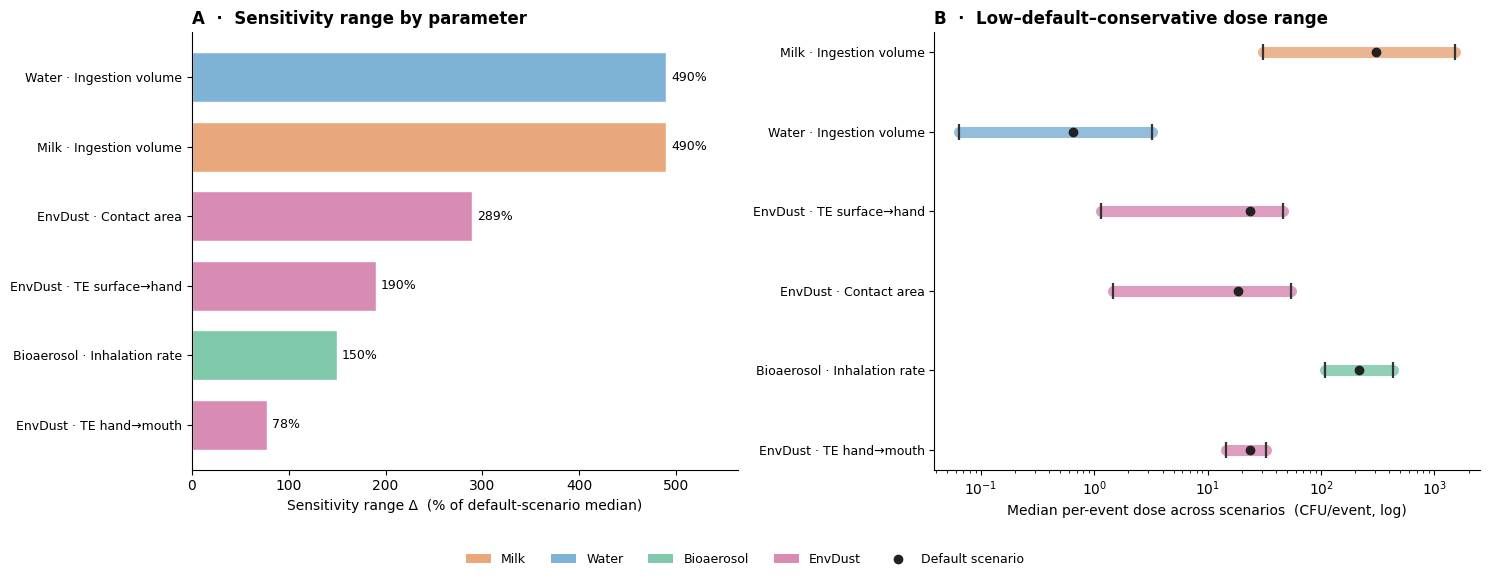

In [10]:
"""
sensitivity_tornado.py
------------------------------------------------------------------------------
Tornado visualization of the sensitivity analysis.

Two complementary views:
  (A) Delta tornado  - horizontal bars ranking each matrix/parameter by the
      sensitivity range delta (% of default median), the metric defined in
      the methods. One bar per matrix-parameter, longest at top.
  (B) Low/Default/High tornado - for each matrix-parameter, a bar spanning the
      mean per-farm median dose from the low to the conservative scenario, with
      the default marked, on a log10 x-axis (CFU/event).

Reads sensitivity_delta.csv and sensitivity_matrix_summary.csv produced by
sensitivity_analysis.py. Run that script first.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DELTA = "sensitivity_delta.csv"
SUMMARY = "sensitivity_matrix_summary.csv"

# consistent matrix colours (match the ridgeline figure)
MATRIX_COLOUR = {
    "Milk": "#E8A87C", "Water": "#7FB3D5",
    "Bioaerosol": "#7FC8A9", "EnvDust": "#D98CB3",
}
PARAM_LABEL = {
    "V_ingest_mL": "Ingestion volume",
    "IR_m3_h": "Inhalation rate",
    "A_contact_cm2": "Contact area",
    "TE_surface_hand": "TE surface→hand",
    "TE_hand_mouth": "TE hand→mouth",
}


def row_label(matrix, param):
    return f"{matrix} · {PARAM_LABEL.get(param, param)}"


# ---------------------------------------------------------------------------
def panel_delta(ax, dlt):
    d = dlt.sort_values("delta_pct")
    labels = [row_label(m, p) for m, p in zip(d.matrix, d.parameter)]
    colours = [MATRIX_COLOUR[m] for m in d.matrix]
    y = np.arange(len(d))
    ax.barh(y, d.delta_pct, color=colours, edgecolor="white", height=0.72)
    for yi, v in zip(y, d.delta_pct):
        ax.text(v + max(d.delta_pct) * 0.01, yi, f"{v:.0f}%",
                va="center", ha="left", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Sensitivity range Δ  (% of default-scenario median)",
                  fontsize=10)
    ax.set_xlim(0, max(d.delta_pct) * 1.15)
    ax.set_title("A  ·  Sensitivity range by parameter",
                 loc="left", fontweight="bold", fontsize=12)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def panel_range(ax, summ):
    piv = summ.pivot_table(index=["matrix", "parameter"],
                           columns="scenario", values="median_CFU")
    piv = piv.reset_index()
    # order rows by log-span (high/low), widest at top
    piv["span"] = np.log10(piv["conservative"]) - np.log10(piv["low"])
    piv = piv.sort_values("span")
    y = np.arange(len(piv))
    for yi, (_, r) in zip(y, piv.iterrows()):
        lo, de, hi = r["low"], r["default"], r["conservative"]
        c = MATRIX_COLOUR[r["matrix"]]
        ax.plot([lo, hi], [yi, yi], color=c, lw=8, alpha=0.85,
                solid_capstyle="round", zorder=1)
        ax.plot([de], [yi], "o", color="#222", ms=6, zorder=3)       # default
        ax.plot([lo], [yi], "|", color="#333", ms=12, mew=1.6, zorder=3)
        ax.plot([hi], [yi], "|", color="#333", ms=12, mew=1.6, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([row_label(m, p) for m, p in
                        zip(piv.matrix, piv.parameter)], fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("Median per-event dose across scenarios  (CFU/event, log)",
                  fontsize=10)
    ax.set_title("B  ·  Low–default–conservative dose range",
                 loc="left", fontweight="bold", fontsize=12)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def main():
    dlt = pd.read_csv(DELTA)
    summ = pd.read_csv(SUMMARY)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
    panel_delta(axes[0], dlt)
    panel_range(axes[1], summ)

    # shared matrix-colour legend
    handles = [Patch(facecolor=c, label=m) for m, c in MATRIX_COLOUR.items()]
    handles += [plt.Line2D([0], [0], marker="o", color="#222", lw=0,
                           label="Default scenario")]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig("sensitivity_tornado.png", dpi=150, bbox_inches="tight")
    print("Saved: sensitivity_tornado.png")


if __name__ == "__main__":
    main()

/tmp/ipykernel_946/3571489294.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.04, 1, 1))


Saved: sensitivity_main.png


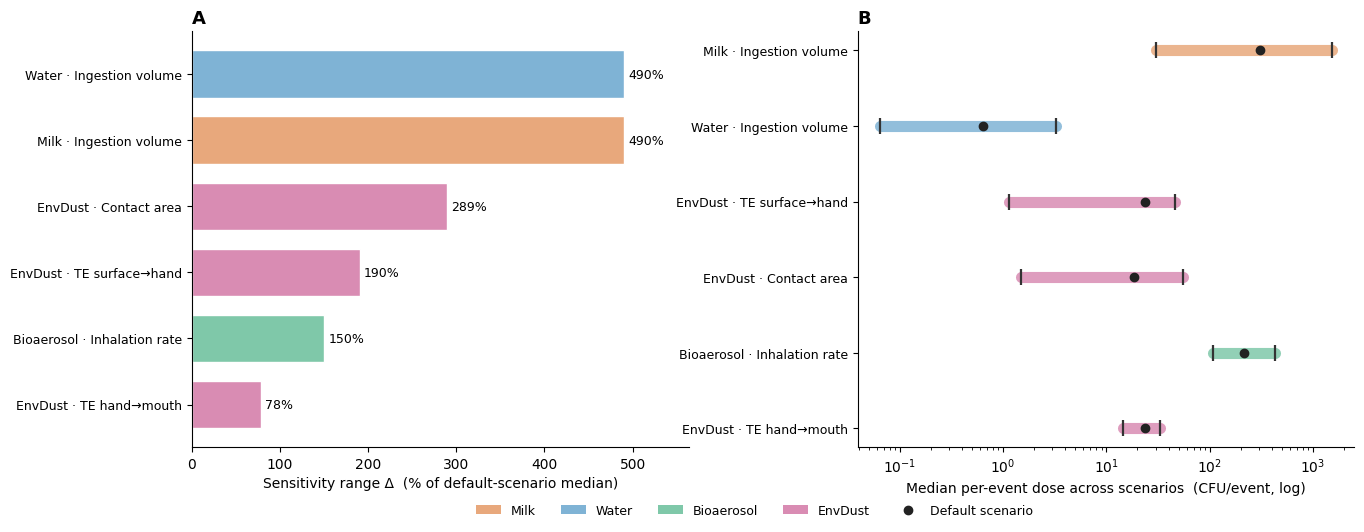

In [11]:
"""
sensitivity_main_figure.py
------------------------------------------------------------------------------
Main sensitivity figure (two panels, labelled A and B only, no descriptive
panel titles):

  A  Scenario sensitivity range (delta, % of default median), all pathways
  B  Low-default-conservative median dose range (CFU/event, log scale)

Reads sensitivity_delta.csv and sensitivity_matrix_summary.csv from
sensitivity_analysis.py.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

DELTA = "sensitivity_delta.csv"
SUMMARY = "sensitivity_matrix_summary.csv"

MATRIX_COLOUR = {"Milk": "#E8A87C", "Water": "#7FB3D5",
                 "Bioaerosol": "#7FC8A9", "EnvDust": "#D98CB3"}
PARAM_LABEL = {"V_ingest_mL": "Ingestion volume", "IR_m3_h": "Inhalation rate",
               "A_contact_cm2": "Contact area",
               "TE_surface_hand": "TE surface→hand",
               "TE_hand_mouth": "TE hand→mouth"}


def row_label(m, p):
    return f"{m} · {PARAM_LABEL.get(p, p)}"


def panel_delta(ax, dlt):
    d = dlt.sort_values("delta_pct")
    y = np.arange(len(d))
    ax.barh(y, d.delta_pct, color=[MATRIX_COLOUR[m] for m in d.matrix],
            edgecolor="white", height=0.72)
    for yi, v in zip(y, d.delta_pct):
        ax.text(v + d.delta_pct.max() * 0.01, yi, f"{v:.0f}%",
                va="center", ha="left", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels([row_label(m, p) for m, p in zip(d.matrix, d.parameter)],
                       fontsize=9)
    ax.set_xlim(0, d.delta_pct.max() * 1.15)
    ax.set_xlabel("Sensitivity range Δ  (% of default-scenario median)",
                  fontsize=10)
    ax.set_title("A", loc="left", fontweight="bold", fontsize=13)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def panel_range(ax, summ):
    piv = (summ.pivot_table(index=["matrix", "parameter"], columns="scenario",
                            values="median_CFU").reset_index())
    piv["span"] = np.log10(piv["conservative"]) - np.log10(piv["low"])
    piv = piv.sort_values("span")
    y = np.arange(len(piv))
    for yi, (_, r) in zip(y, piv.iterrows()):
        c = MATRIX_COLOUR[r["matrix"]]
        ax.plot([r["low"], r["conservative"]], [yi, yi], color=c, lw=8,
                alpha=0.85, solid_capstyle="round", zorder=1)
        ax.plot([r["low"]], [yi], "|", color="#333", ms=12, mew=1.6, zorder=3)
        ax.plot([r["conservative"]], [yi], "|", color="#333", ms=12, mew=1.6,
                zorder=3)
        ax.plot([r["default"]], [yi], "o", color="#222", ms=6, zorder=4)
    ax.set_yticks(y)
    ax.set_yticklabels([row_label(m, p) for m, p in
                        zip(piv.matrix, piv.parameter)], fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("Median per-event dose across scenarios  (CFU/event, log)",
                  fontsize=10)
    ax.set_title("B", loc="left", fontweight="bold", fontsize=13)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def main():
    dlt = pd.read_csv(DELTA)
    summ = pd.read_csv(SUMMARY)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4),
                             gridspec_kw=dict(wspace=0.34))
    panel_delta(axes[0], dlt)
    panel_range(axes[1], summ)

    handles = [Patch(facecolor=c, label=m) for m, c in MATRIX_COLOUR.items()]
    handles.append(Line2D([0], [0], marker="o", color="#222", lw=0,
                          label="Default scenario"))
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig("sensitivity_main.png", dpi=150, bbox_inches="tight")
    print("Saved: sensitivity_main.png")


if __name__ == "__main__":
    main()